# Variable Transformation

## Mathematical Transofmations

- apply different mathematical formula on our columns
- What will happen?
- The data distribution pdf (probability density function) converts into normal distribution or normal function

> Normal distribution means data is symmetrically distrituted around the mean. 

In ML, statistical algos are 
 - linear regression
 - logestic regression

We work with the assumption that the data is normal. If not we make it normal.

On the other hand, algos like Random forest does not care if your data is normally distributed or not. 

In order to do normal distribution, we can do following things:
- log transform
- Reciprocal transform
- Power transform

Others:
- Box -Cox
- Yeo Johnson

Sklearn

1) Function Transform
- log tranform
- reciprocal transform
- square root transform
- custom transform
2) Power Transform
- Box -Cox
- Yeo Johnson
3) Quantile Transform

#### How to check if the data is normal

first use seaborn
second is pandas.skew
third is qqplot


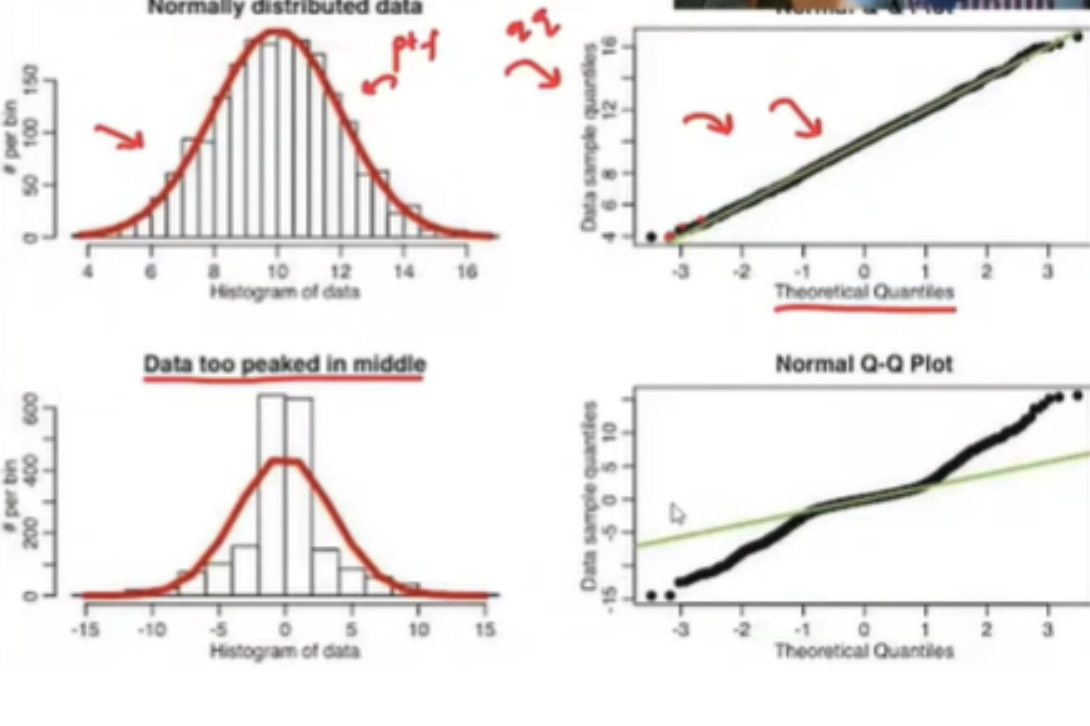

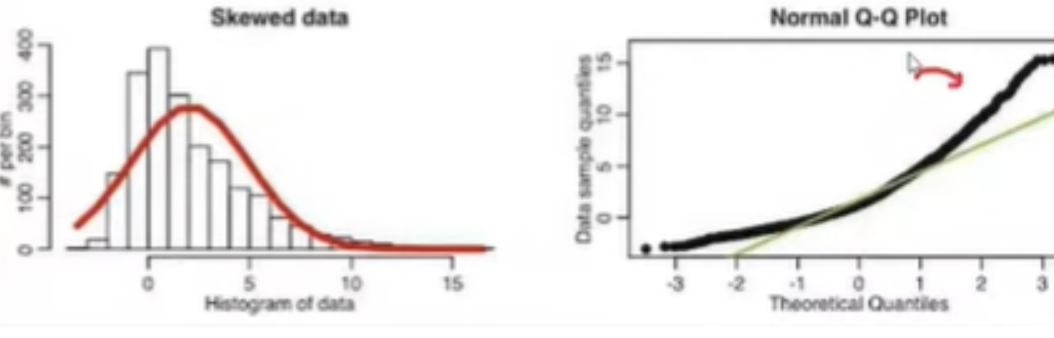

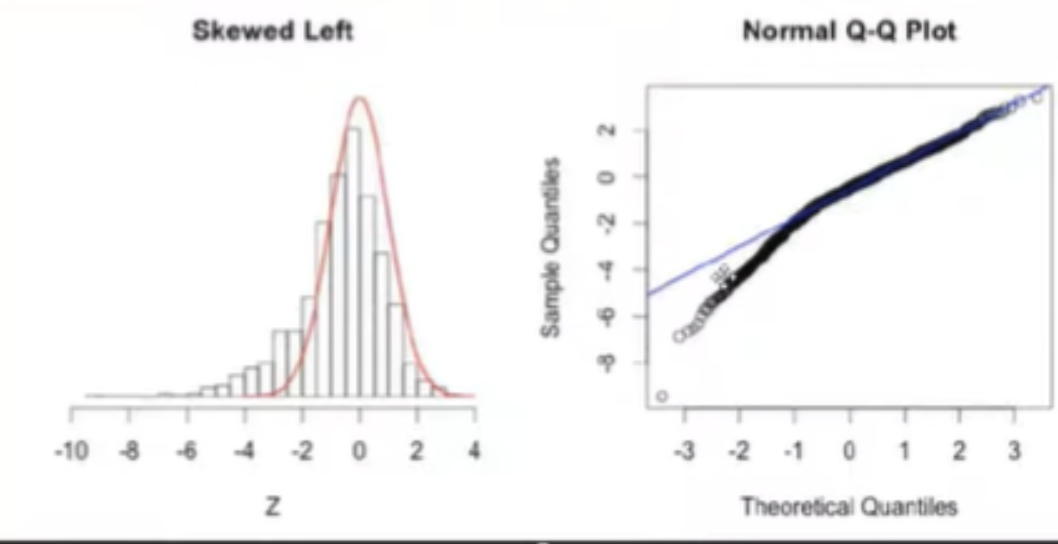

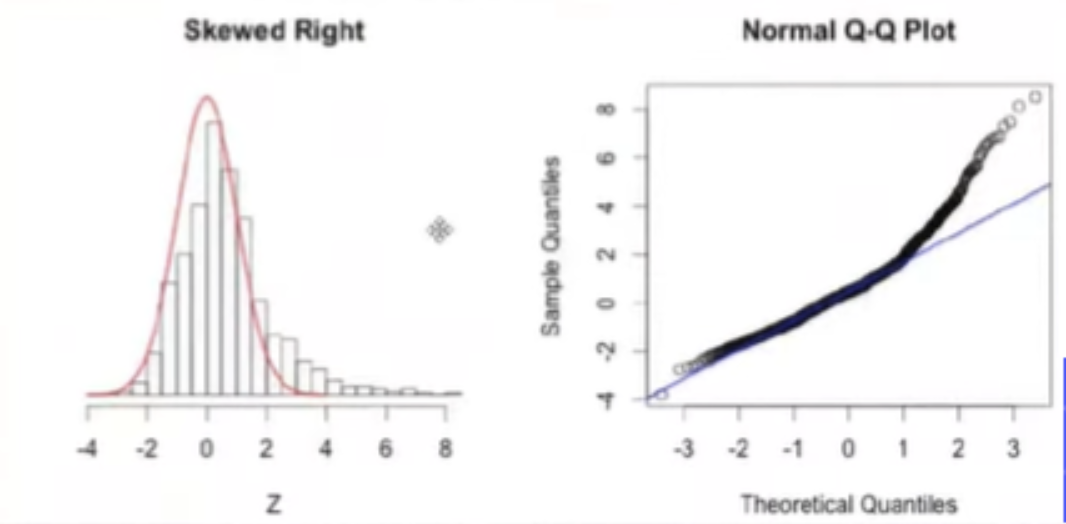

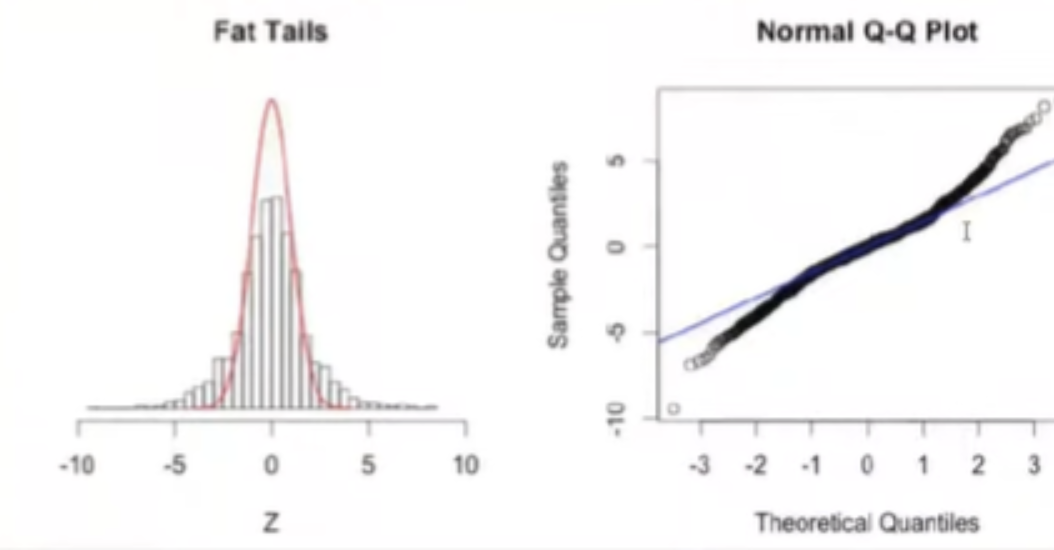

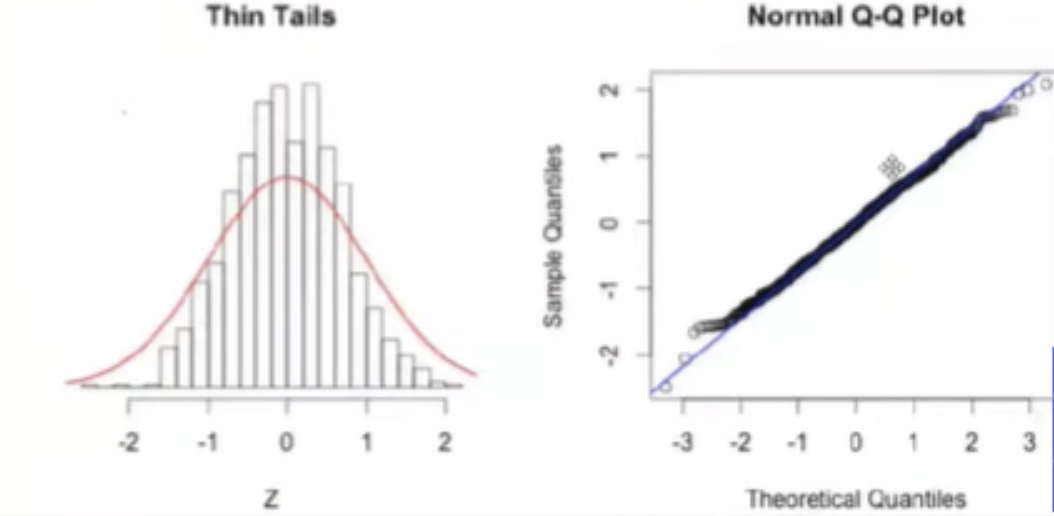

If data is on line its means data is more normal distribution

## Log transform

In [ ]:
- It will not apply on -ve negative values.
- we will apply log transform on right skewed data.


### Other transforms

- Reciprocal
    - In reciprocal small values becomes larger and larger values becomes smaller.
- Square
    - sq square data is used for left skewed data
- Square root

# Practical

In [21]:
import numpy as np 
import pandas as pd

In [22]:
import scipy.stats as stats # it is used for statistical tests and distributions. We use this for qq plot

import matplotlib.pyplot as plt # 
import seaborn as sns # it is used for statistical data visualization

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import cross_val_score # it is used for cross-validation of a model

from sklearn.linear_model import LogisticRegression # model regression is used for predicting a binary outcome
from sklearn.tree import DecisionTreeClassifier # decision tree is used for classification and regression tasks

from sklearn.preprocessing import FunctionTransformer # it is used for applying custom functions to transform data
from sklearn.compose import ColumnTransformer # it is used for applying different transformations to different columns of data


In [23]:
df = pd.read_csv("titanic.csv",usecols=["Age", "Fare", "Survived"])

In [24]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [25]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [26]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
#  its means if there are any missing values in the "Age" column, they will be replaced with the mean age of the existing values in that column.

In [27]:
X = df.iloc[:,1:3] # iloc means index location
y = df.iloc[:,0]

In [28]:
X

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [29]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

## Step 1: Tain test split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_9580/3867851249.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train ["Age"])


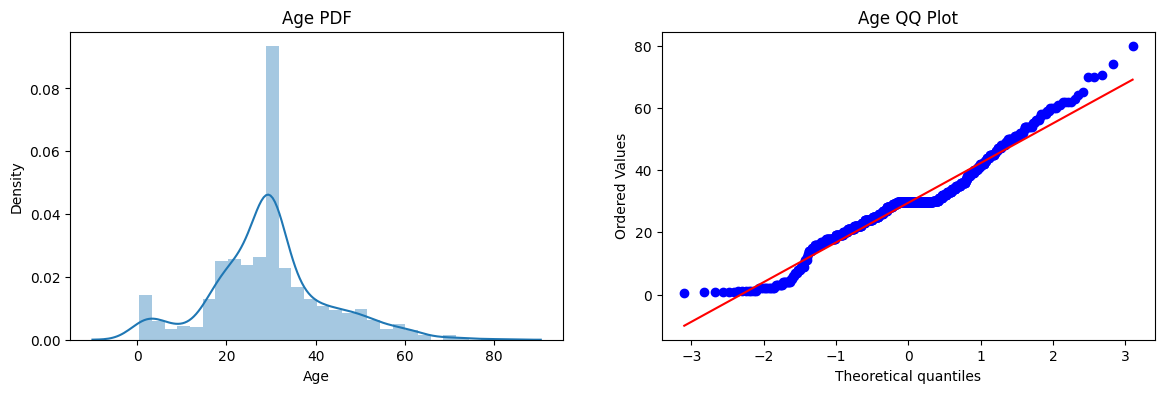

In [31]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.distplot(X_train ["Age"])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.show()


/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_9580/520796935.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train ["Fare"])


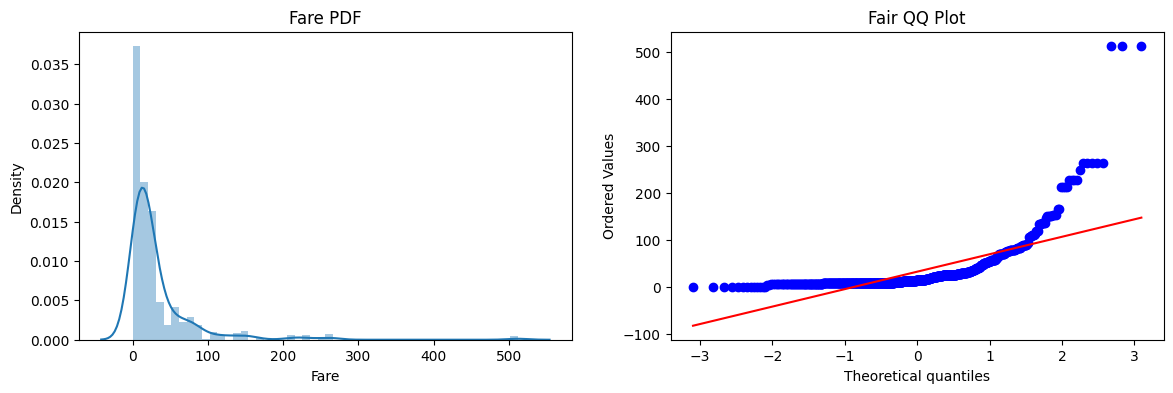

In [32]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.distplot(X_train ["Fare"])
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
plt.title("Fair QQ Plot")

plt.show()

This is right skewed so we use log transformaton

## Step 2: fill null values

In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## without transformation

In [34]:
clf = LogisticRegression() 
clf2 = DecisionTreeClassifier()

In [35]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_predict = clf.predict(X_test)
y_predict1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_predict))
print("Accuracy DT",accuracy_score(y_test,y_predict1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6703910614525139


## with transformation

In [36]:
trf = FunctionTransformer(func=np.log1p)
# np.log1p add x + 1 so no value will be 0. If there is no 0 in your data you can use np.log


In [37]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

y_predict = clf.predict(X_test_transformed)
y_predict1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_predict))
print("Accuracy DT",accuracy_score(y_test,y_predict1))

Accuracy LR 0.5865921787709497
Accuracy DT 0.4134078212290503


## Cross Validation

In [38]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression() 
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf,X_transformed,y,scoring="accuracy",cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring="accuracy",cv=10)))

LR 0.678027465667915
DT 0.6599750312109862


In [39]:
import numpy as np
np.isnan(X_transformed).sum()


Age     0
Fare    0
dtype: int64

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [41]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", LogisticRegression(max_iter=1000))
])

dt_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", DecisionTreeClassifier())
])

In [43]:
print(
    "LR",
    np.mean(cross_val_score(lr_pipeline, X_transformed, y, scoring="accuracy", cv=10))
)

print(
    "DT",
    np.mean(cross_val_score(dt_pipeline, X_transformed, y, scoring="accuracy", cv=10))
)


LR 0.678027465667915
DT 0.654394506866417


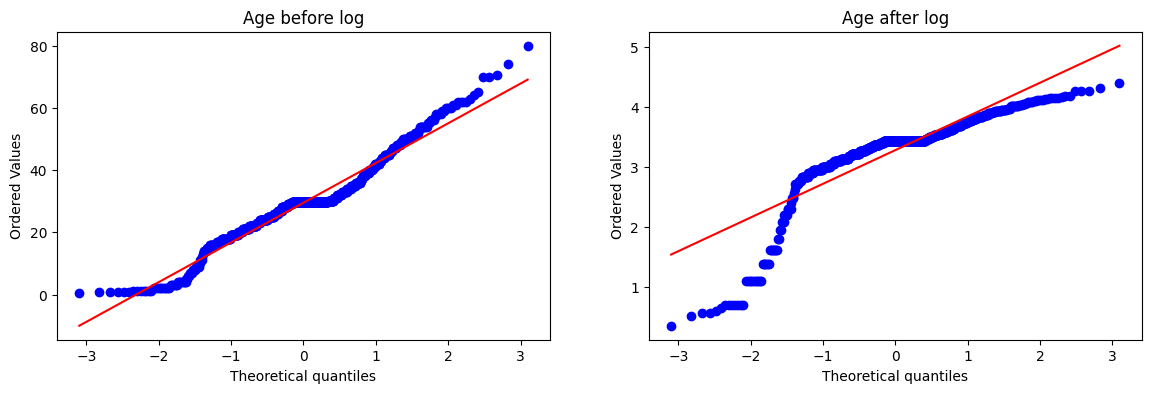

In [44]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train[:, 0], dist="norm", plot=plt)
plt.title("Age before log")

plt.subplot(122)
stats.probplot(X_train_transformed[:, 0], dist="norm", plot=plt)
plt.title("Age after log")

plt.show()


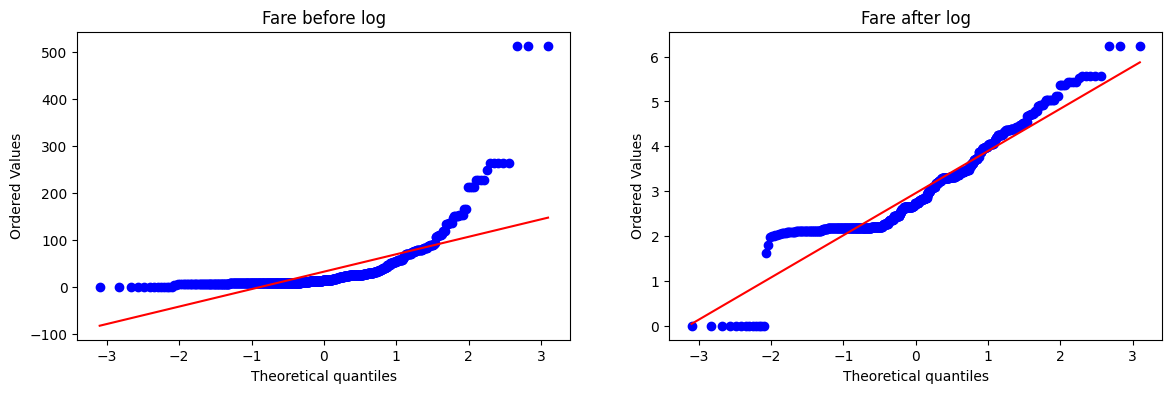

In [45]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train[:, 1], dist="norm", plot=plt)
plt.title("Fare before log")

plt.subplot(122)
stats.probplot(np.log1p(X_train[:, 1]), dist="norm", plot=plt)
plt.title("Fare after log")

plt.show()


In [51]:
X = df.iloc[:, 1:3]   # Age, Fare



In [52]:
X

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [53]:
X_train = pd.DataFrame(X_train, columns=["Age", "Fare"])
X_test  = pd.DataFrame(X_test, columns=["Age", "Fare"])


In [54]:
X_test

,Age,Fare
0,29.699118,15.2458
1,31.000000,10.5000
2,20.000000,7.9250
3,6.000000,33.0000
4,14.000000,11.2417
...,...,...
174,17.000000,7.1250
175,29.699118,7.2250
176,38.000000,31.3875
177,17.000000,10.5000


In [55]:
X_train

,Age,Fare
0,45.500000,28.5000
1,23.000000,13.0000
2,32.000000,7.9250
3,26.000000,7.8542
4,6.000000,31.2750
...,...,...
707,21.000000,7.6500
708,29.699118,31.0000
709,41.000000,14.1083
710,14.000000,120.0000


In [56]:
trf2 = ColumnTransformer(
    [("log", FunctionTransformer(np.log1p), ["Fare"])],
    remainder="passthrough"
)

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2  = trf2.transform(X_test)


In [57]:

# Transform train and test data
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2  = trf2.transform(X_test)

# Models
clf  = LogisticRegression()
clf2 = DecisionTreeClassifier()

# Train models
clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

# Predictions
y_pred  = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

# Accuracy
print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.6703910614525139
Accuracy DT: 0.6480446927374302


In [58]:
X = df[["Age", "Fare"]]
y = df["Survived"]


In [59]:
lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("log_fare", ColumnTransformer(
        [("log", FunctionTransformer(np.log1p), ["Fare"])],
        remainder="passthrough"
    )),
    ("model", LogisticRegression(max_iter=1000))
])


In [60]:
lr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('log_fare', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [62]:
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("log_fare", ColumnTransformer(
        [("log", FunctionTransformer(np.log1p), ["Fare"])],
        remainder="passthrough"
    )),
    ("model", DecisionTreeClassifier())
])


In [64]:
dt_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('log_fare', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [66]:
print(
    "LR",
    np.mean(cross_val_score(lr_pipeline, X, y, scoring="accuracy", cv=10))
)

print(
    "DT",
    np.mean(cross_val_score(dt_pipeline, X, y, scoring="accuracy", cv=10))
)


LR 0.6589013732833957
DT 0.6644319600499375


## Reciprocal transform

In [68]:
def apply_transform(transform):
    
    # Features and target (keep as DataFrame)
    X = df.iloc[:, 1:3]   # Age, Fare
    y = df.iloc[:, 0]     # Survived

    # ColumnTransformer (apply transform only on Fare)
    trf = ColumnTransformer(
        [("log", FunctionTransformer(transform), ["Fare"])],
        remainder="passthrough"
    )

    # Transform features
    X_trans = trf.fit_transform(X)

    # Model
    clf = LogisticRegression(max_iter=1000)

    # Cross-validation accuracy
    print(
        "Accuracy:",
        np.mean(cross_val_score(clf, X_trans, y, scoring="accuracy", cv=10))
    )

    # QQ plots
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    stats.probplot(X["Fare"], dist="norm", plot=plt)
    plt.title("Fare Before Transform")

    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist="norm", plot=plt)
    plt.title("Fare After Transform")

    plt.show()

Accuracy: 0.6195131086142323


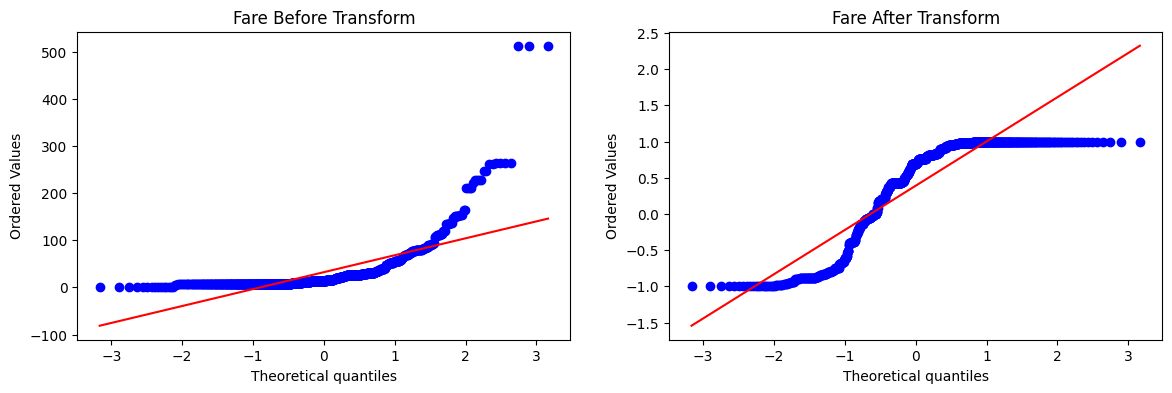

In [69]:
apply_transform(np.sin)# reciprocal transform